# ReLU

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/main/docs/learn/layers/03-ReLU.ipynb)
[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/main/docs/learn/layers/03-ReLU.ipynb)
[![Open in Docs](https://img.shields.io/badge/Open%20in-Docs-blue?logo=readthedocs)](https://mitchell-mirano.github.io/sorix/latest/learn/layers/03-ReLU)


The **ReLU** layer implements the *Rectified Linear Unit* activation function, one of the most widely used nonlinearities in deep learning due to its simplicity, computational efficiency, and favorable gradient properties. ReLU introduces nonlinearity by applying an element-wise thresholding operation to its input.

## Mathematical definition

Let $\mathbf{X} \in \mathbb{R}^{N \times d}$ be an input tensor representing a batch of $N$ samples with $d$ features. The ReLU activation is defined element-wise as:

$$\operatorname{ReLU}(x) = \max(0, x)$$

Applied to a tensor, this yields:

$$\mathbf{Y} = \operatorname{ReLU}(\mathbf{X}), \quad Y_{ij} = \max(0, X_{ij})$$

## Backward computation (gradient)

The derivative of the ReLU function is given by:

$$\frac{d}{dx} \operatorname{ReLU}(x) = \begin{cases} 1, & x > 0 \\ 0, & x \le 0 \end{cases}$$

During backpropagation, the gradient with respect to the input $\mathbf{X}$ is computed by applying the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{X}} = \frac{\partial \mathcal{L}}{\partial \mathbf{Y}} \odot \mathbb{I}(\mathbf{X} > 0)$$

where $\mathbb{I}(\cdot)$ is the indicator function and $\odot$ represents element-wise multiplication.

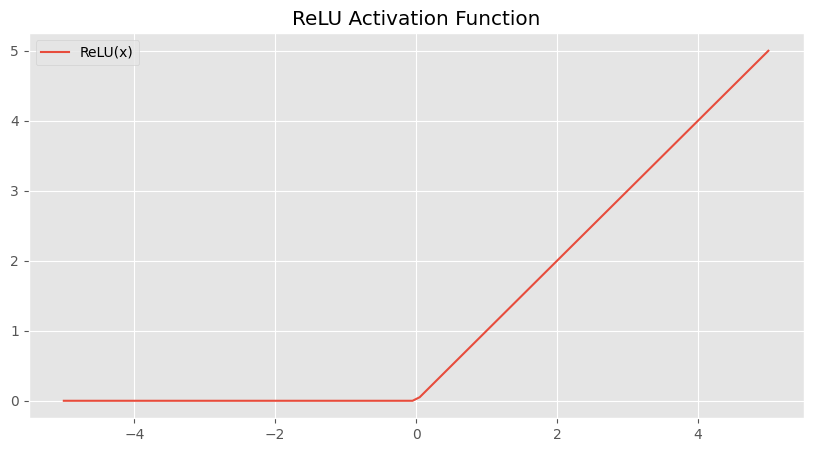

In [1]:
# Setup and demo
import numpy as np
import matplotlib.pyplot as plt
from sorix import tensor
from sorix.nn import ReLU

plt.style.use('ggplot')

x_vals = np.linspace(-5, 5, 100)
X = tensor(x_vals, requires_grad=True)
relu = ReLU()
Y = relu(X)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, Y.data, label='ReLU(x)', color='#e74c3c')
plt.title('ReLU Activation Function')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
X = tensor([-2.0, -1.0, 0.0, 1.0, 2.0], requires_grad=True)
Y = relu(X)
Y.sum().backward()

print(f'Input:     {X.data}')
print(f'Output:    {Y.data}')
print(f'Gradients: {X.grad}')

Input:     [-2. -1.  0.  1.  2.]
Output:    [0. 0. 0. 1. 2.]
Gradients: tensor([0., 0., 0., 1., 1.])
